# STAT301:  Group 1 - Final Report

**Group Number:** 1

**Group Members:**

Jessica Wang 70447628

Carmen Zhang 21533252

Reyhan Pamungkas 25383597

**Date:** Dec 2

## Introduction

The dataset **Marketing Campaign** contains information about customers of a Portuguese retail company. It includes demographic, financial, and behavioural attributes that describe customer purchasing habits and campaign responses. The dataset consists of **2,240 observations** and **29 variables**. 

**Question**:
We want to examine the association between whether a customer accepts the latest marketing campaign offer (response) and predictors related to demographic characteristics (e.g., income, age, marital status, family composition) and behavioural characteristics (e.g., spending on different product categories, purchase channels, website visits, and past campaign responses).

**Response**:
`Response` (binary: 1 = accepted the campaign, 0 = did not accept).

**Explanation**:
The question focuses primarily on inference, as we aim to understand which factors significantly affect campaign acceptance.

## Method and Result

### a) Data

In order for companies to sell product in more efficient way, we could analyze customer personality and then modify products. "Customer Personality Analysis" dataset is aiming to analyze the purchase behaviour of specific customer segments. It contains 29 columns and 2240 that describing customer demographic, purchasing behaviour on specific products, purchase behaviour based on promotion, and places to buy.


**Variable Summary**



`ID`: Customer's Identification **(Numerical Variable)**

`Year_Birth`: Customer's year of birth **(Numerical Variable)**

`Education`: Customer's education level **(Categorical Variable)**

`Marital_Status`: Customer's marital status **(Categorical Variable)**

`Income`: Customer's household income (per year) **(Continuous Numerical Variable)**

`Kindhome`: Numbers of child in customer's household **(Numerical Variable)**

`Teehome`: Number of teenagers in customer's household **(Numerical Variable)**

`Dt_Customer`: Date of customer's enrollment with company **(Numerical Variable)**

`Recency`: Number of days since customer's last purchase **(Numerical Variable)**



**Continuous Numerical Variables:**

`MntWines`: Money purchased on wine (in last 2 years)

`MntFruits`: Money purchased on fruits (in last 2 years)

`MntMeatProducts`: Money purchased on meat (in last 2 years)

`MntFishProducts`: Money purchased on fish (in last 2 years)

`MntSweetProducts`: Money purchased on sweets (in last 2 years)

`MntGoldProds`: Money purchased on gold (in last 2 years

**Binary(0/1) Variables:**

`AcceptedCmp1`: 1 if customer accepted the offer in the 1st campaign, 0 otherwise

`AcceptedCmp2`: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise

`AcceptedCmp3`: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise

`AcceptedCmp4`: 1 if customer accepted the offer in the 4th campaign, 0 otherwise

`AcceptedCmp5`: 1 if customer accepted the offer in the 5th campaign, 0 otherwise

`Response`: 1 if customer accepted the offer in the last campaign, 0 otherwise

`Complain`: Customer's complains (1 if complained in the last 2 years; 0 otherwise)

**Numerical Integer Variables:**

`NumDealsPurchases`: Count how many purchases made with discount

`NumWebPurchases`: Count how many purchases made through company’s website

`NumCatalogPurchases`: Count how many purchases made using catalogue

`NumStorePurchases`: Count how many purchases made in store

`NumWebVisitsMonth`: Count how many visits to company's website in the last month

`Z_CostConntact`: Cost for contacting one customer (3$)

`Z_Revenue`: Revenue generated per customer after once accpet the campaign (11$)

**Source and Information**

The "Customer Personality Analysis" dataset is provided by Dr. Omar Romero-Hernandez, and we could get access to this dataset on "Kaggle" website. Since this dataset contains some "N/A" columns in `Income` variable because some customers might want to protect their private information, we need to drop "N/A" for incompleted information before using the dataset. 

Patel, A. (2021). Customer Personality Analysis. Kaggle. https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis/data

**Pre-selection**

Consider for future data analysis, some redundant variables could be discarded. For example, `AcceptedCmp1` ~ `AcceptedCmp5` could be dropped, or convert those 5 variables into one to represent the total amount of accept after five campaigns. Since this project will make inferences based on the most recent marketing campaign, variables `AcceptedCmp1` ~ `AcceptedCmp5` would be dropped. Also, some variables will be excluded before modelling: `ID` is a unique identifier that provides no predictive value, `Dt_Customer` represents the enrollment date and is not directly relevant to response behaviour, and both `Z_CostContact` and `Z_Revenue` are constant across all observations, offering no useful information for prediction.

### b) Exploratory Data Analysis (EDA)

In [1]:
#Load libraries
library(tidyverse)
library(tidymodels)
library(readr)
library(utils)
library(MASS)
library(car)
library(pROC)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.2.1     ✔ tune         1.2.1
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.1.0
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

The data could be downloaded from: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis.

In [2]:
#Read the data into R

url <- "https://raw.githubusercontent.com/ywang550/stat301final-project/refs/heads/main/marketing_campaign.csv"
marketing <- read_delim(url, delim = "\t") 
head(marketing)

Rows: 2240 Columns: 29
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (3): Education, Marital_Status, Dt_Customer
dbl (26): ID, Year_Birth, Income, Kidhome, Teenhome, Recency, MntWines, MntF...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,⋯,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5524,1957,Graduation,Single,58138,0,0,04-09-2012,58,635,⋯,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344,1,1,08-03-2014,38,11,⋯,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613,0,0,21-08-2013,26,426,⋯,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646,1,0,10-02-2014,26,11,⋯,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293,1,0,19-01-2014,94,173,⋯,5,0,0,0,0,0,0,3,11,0
7446,1967,Master,Together,62513,0,1,09-09-2013,16,520,⋯,6,0,0,0,0,0,0,3,11,0


In [3]:
#Select relevant variables and remove unwanted marital status categories 
#And remove extreme outliers (top 1% of numeric predictors)

numeric_vars <- c("Income", "MntWines", "MntFruits", 
                  "MntMeatProducts", "MntFishProducts", 
                  "MntSweetProducts", "MntGoldProds")
marketing <- marketing %>%
    filter(!Marital_Status %in% c("Absurd", "Alone", "YOLO", "Widow")) %>%
    dplyr::select(-ID, -Dt_Customer, -Z_CostContact, -Z_Revenue, 
           -AcceptedCmp1, -AcceptedCmp2, -AcceptedCmp3, -AcceptedCmp4, -AcceptedCmp5) %>%
    drop_na() %>%
    mutate(
    Response = factor(Response, levels = c(0,1), labels = c("No", "Yes")),
    Education = as.factor(Education)) %>%
    filter(across(all_of(numeric_vars),
                ~ .x < quantile(.x, 0.99, na.rm = TRUE)))
    
head(marketing)

Warning message:
“Using `across()` in `filter()` was deprecated in dplyr 1.0.8.
ℹ Please use `if_any()` or `if_all()` instead.”


Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
<dbl>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1957,Graduation,Single,58138,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,Yes
1954,Graduation,Single,46344,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,No
1965,Graduation,Together,71613,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,No
1984,Graduation,Together,26646,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,No
1981,PhD,Married,58293,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,No
1967,Master,Together,62513,0,1,16,520,42,98,0,42,14,2,6,4,10,6,0,No


**Visualization**

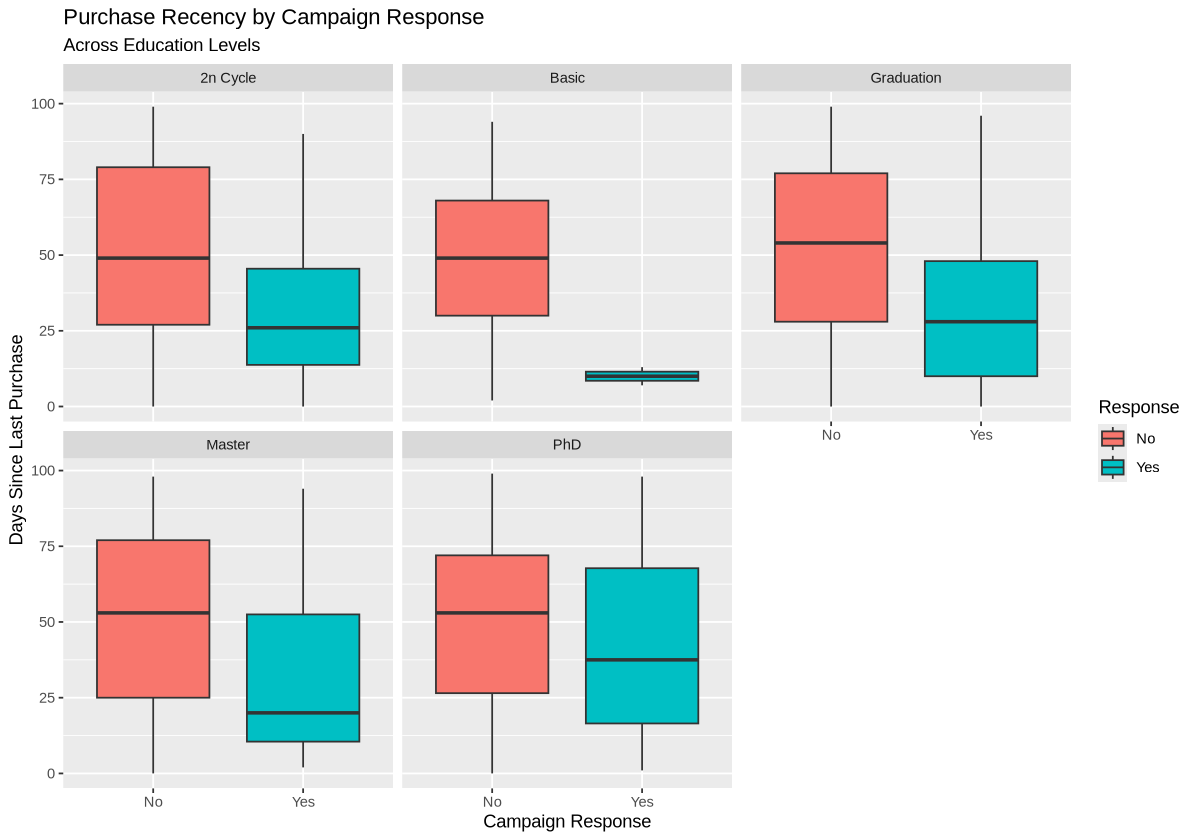

In [4]:
options(repr.plot.width = 10, height = 6)

market_plot1 <- marketing %>%
    ggplot(aes(x = Response, y = Recency, fill = Response)) +
    geom_boxplot() +
    facet_wrap(~ Education) +
    labs(title = "Purchase Recency by Campaign Response",
       subtitle = "Across Education Levels",
       x = "Campaign Response",
       y = "Days Since Last Purchase",
       fill = "Response")


market_plot1

We use boxplot first to show the relationship between the response variable(`Response`) and predictors (`Recency`, `Education`). These variables are selected because they reflect customers' spending capacity and engagement of purchasing goods. `Recency` is selected as it demonstrates a clear distribution that shows the difference between nonresponders and responders among education level.

The boxplot clearly indicates that the median of days since last purchase with people response "no" is relatively higher comparing with people response "yes", among all education level. That make sense since people who accepted the campaign are more likely to make recent purchases.

Based on the result we got so far, I could suggest company to prioritize customers who have purchased recently (for example, within a month) because they are more receptive to marketing campaign.

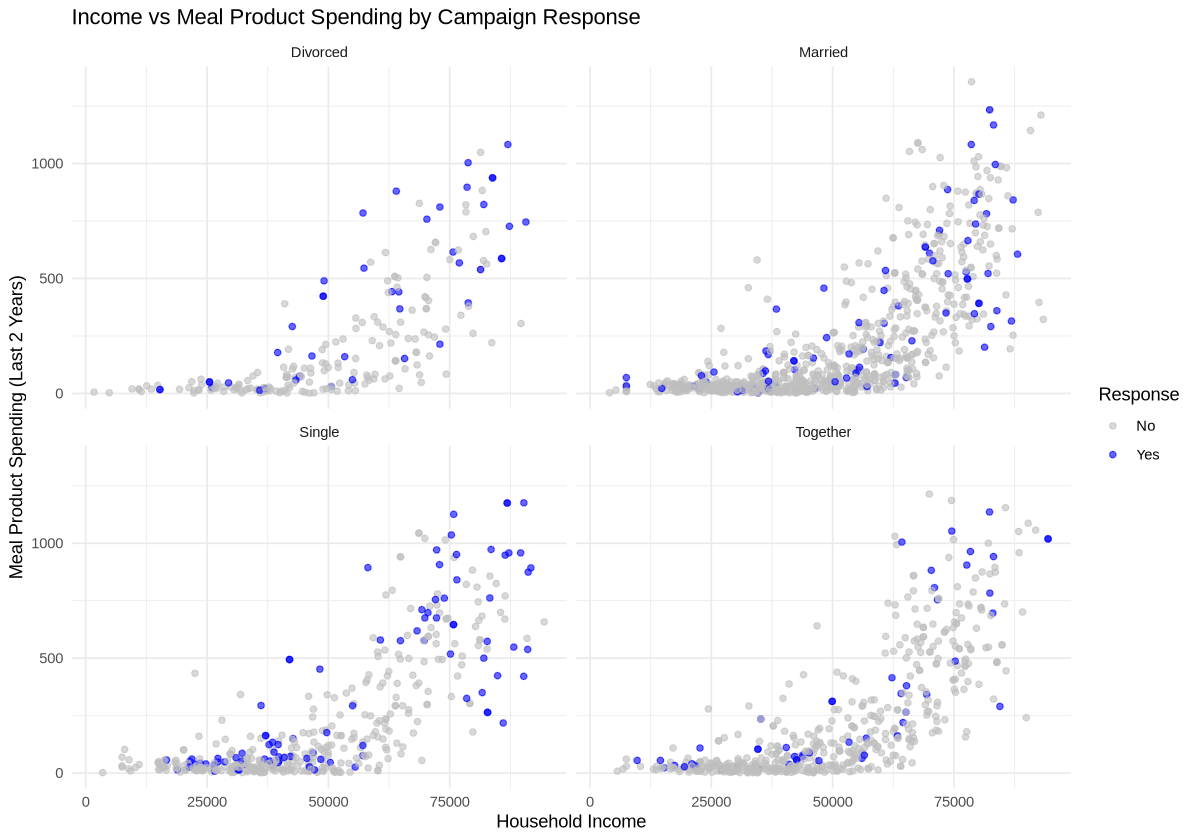

In [5]:
#Visualization using MULTIPLE behaviour factors
market_plot2 <- ggplot(marketing,
       aes(x = Income,
           y = MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts,   # combined behaviour factor
           color = as.factor(Response))) +
  geom_point(alpha = 0.6, size = 1.5) +
  facet_wrap(~ Marital_Status) +
  scale_color_manual(values = c("No" = "gray", "Yes" = "blue")) +
  labs(
    title = "Income vs Meal Product Spending by Campaign Response",
    x = "Household Income",
    y = "Meal Product Spending (Last 2 Years)",
    color = "Response"
  ) +
  theme_minimal(base_size = 11)

market_plot2

This plot is relevant because it visualizes how household income, meal spending, and marital status jointly relate to campaign response, helping identify which demographic–behaviour patterns are associated with offer acceptance. Using a combined spending metric makes the visualization more aligned with the research question, as it captures multiple purchasing behaviour rather than a single product category. Removing sparse categories and outliers allows the meaningful segments to be compared more clearly.

The plot shows a strong positive relationship between income and total product spending across all marital-status groups, with campaign responders more frequently appearing in the upper-right regions of the panels. The patterns are most pronounced for “Single” and "Divorced" customers, where higher spenders tend to be more responsive to the campaign. In contrast, the “Together” group shows fewer high-spending responders and less obvious clustering.

The visualization suggests that multiple spending behaviours may be a more informative predictor of campaign acceptance than individual product categories, supporting the choice of combining spending variables. It also highlights heterogeneity across marital-status groups, with some segments showing stronger alignment between high spending and response. Finally, the plot indicates that any future modelling should consider potential income–spending interactions and uneven sample sizes across marital groups, which could affect model stability.

### c) Methods: Plan

Proposed Method: Logistic Regression

Why is this method appropriate?

Logistic regression is appropriate because our response variable, whether the customer accepted the last campaign offer (1 = yes, 0 = no), is binary. This method models the probability of acceptance as a function of demographic variables and behavioural factors, providing interpretable effects in terms of odds ratios.

Which assumptions are required?

- Binary outcome: Logistic regression assumes the response is binary, which fits our data.
- Independence: Each customer’s decision is assumed to be independent of others.
- Linearity of the logit: Predictors are assumed to have a linear relationship with the log-odds of accepting the offer, not with the raw probability.
- No perfect multicollinearity: Predictors should not be perfectly correlated.

What are the potential limitations or weaknesses of the method selected?

- Logit linearity assumption: If predictors have non-linear effects on acceptance probability, logistic regression may misrepresent the true relationship unless interactions or transformations are added.
- Multicollinearity: Highly correlated predictors can inflate variance and make coefficient interpretations unreliable.
- Class imbalance: If very few customers accepted the offer, the model may struggle to learn meaningful patterns without rebalancing or weighting strategies.
- Overdispersion: Logistic regression assumes that the variance of the binary response follows the binomial distribution. If the observed variability in acceptance decisions is larger than expected, standard errors may be underestimated, leading to overly confident significance tests and unreliable inference.

Variable Selection Method: Stepwise Selection

We will use stepwise selection based on AIC to refine our logistic regression model and identify the most important predictors of whether a customer accepts the final marketing campaign offer. This approach is helpful when there are many potential explanatory variables, such as demographic characteristics, spending behaviours, and previous campaign responses. It is not clear which combination contributes most to predicting the outcome. Stepwise selection evaluates models by adding or removing predictors according to statistical criteria, helping us arrive at a more parsimonious and interpretable model.

### d) Code and Results

In [6]:
# Full model (all remaining predictors)
resp_full <- glm(Response ~ .,
                 data = marketing,
                 family = binomial)

# Multicollinearity Check
vif(resp_full)

,GVIF,Df,GVIF^(1/(2*Df))
Year_Birth,1.270009,1,1.126947
Education,1.285365,4,1.031878
Marital_Status,1.107892,3,1.017223
Income,6.636863,1,2.576211
Kidhome,2.178995,1,1.476142
Teenhome,1.888212,1,1.374122
Recency,1.113140,1,1.055054
MntWines,3.305997,1,1.818240
MntFruits,1.918052,1,1.384938
MntMeatProducts,3.426291,1,1.851024


From vif(), no covariates in this model exhibit serious multicollinearity (GVIF^(1/(2*Df)) > sqrt(10)). To improve the model, we will now apply a variable selection method to identify a more optimal model.

In [7]:
# Split the data into training and testing sets
set.seed(123)
resp_split <- initial_split(marketing, prop = 0.7, strata = Response)  # 70% train, stratified by Response
resp_train <- training(resp_split)
resp_test  <- testing(resp_split)

# Fit the full logistic regression model using all predictors
resp_full_train <- glm(Response ~ ., data = resp_train, family = binomial)

# Perform stepwise selection using AIC (backward elimination)
resp_backward <- stepAIC(resp_full_train, direction = "backward", k = 2)

Start:  AIC=847.95
Response ~ Year_Birth + Education + Marital_Status + Income + 
    Kidhome + Teenhome + Recency + MntWines + MntFruits + MntMeatProducts + 
    MntFishProducts + MntSweetProducts + MntGoldProds + NumDealsPurchases + 
    NumWebPurchases + NumCatalogPurchases + NumStorePurchases + 
    NumWebVisitsMonth + Complain

                      Df Deviance    AIC
- Kidhome              1   797.95 845.95
- MntFishProducts      1   797.95 845.95
- Complain             1   797.97 845.97
- Year_Birth           1   798.05 846.05
- MntFruits            1   798.09 846.09
- Income               1   798.31 846.31
- MntSweetProducts     1   798.58 846.58
- NumWebPurchases      1   798.73 846.73
<none>                     797.95 847.95
- MntGoldProds         1   800.00 848.00
- Education            4   807.83 849.83
- NumCatalogPurchases  1   805.48 853.48
- NumDealsPurchases    1   808.19 856.19
- MntWines             1   808.44 856.44
- MntMeatProducts      1   809.95 857.95
- NumWebV

Using stepwise AIC selection, the model progressively removed predictors that did not meaningfully improve model fit. The selected model included a smaller set of variables, such as education level, marital status, Teenhome, Recency, several spending variables (MntWines, MntMeatProducts, MntGoldProds), and purchase behaviours (NumDealsPurchases, NumCatalogPurchases, NumStorePurchases, NumWebVisitsMonth). In contrast, variables such as Income, Kidhome, and several product spending categories did not meaningfully improve the model and were excluded.

This result shows that the most influential predictors of Response are related to:
- Customer engagement and channel usage (e.g., number of purchases through different channels, website visits)
- Spending patterns on certain product categories
- Key demographic and household composition factors like education, marital status, and teenage dependents

The variables most strongly associated with marketing response are behavioural and purchasing characteristics, rather than basic demographics or household characteristics.

In [9]:
# Fit the model using the selected variables
resp_select <- glm(Response ~ Education + Marital_Status + Teenhome + Recency + 
                   MntWines + MntMeatProducts + MntGoldProds + NumDealsPurchases + 
                   NumCatalogPurchases + NumStorePurchases + NumWebVisitsMonth, 
                   data = resp_train,
                   family = binomial)

# Compare the selected model and the full model using ANOVA
anova(resp_select, resp_full_train, test = "Chisq")

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1380,801.5362,NA,NA,NA
2,1372,797.9500,8,3.586205,0.8923973


According to the ANOVA test, there is no significant difference between the full model and the reduced model (p = 0.89) at 5% significance level. This means the extra predictors in the full model do not improve model fit. Therefore, the selected model captures the relationship just as well and is sufficient for explaining the response.

In [10]:
summary(resp_full_train)


Call:
glm(formula = Response ~ ., family = binomial, data = resp_train)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)             2.903e+00  1.699e+01   0.171 0.864316    
Year_Birth             -2.751e-03  8.589e-03  -0.320 0.748784    
EducationBasic         -1.250e+00  1.093e+00  -1.144 0.252647    
EducationGraduation     1.339e-01  3.627e-01   0.369 0.711893    
EducationMaster         6.133e-01  4.074e-01   1.505 0.132292    
EducationPhD            6.450e-01  3.984e-01   1.619 0.105441    
Marital_StatusMarried  -6.205e-01  3.060e-01  -2.028 0.042584 *  
Marital_StatusSingle    3.873e-01  3.124e-01   1.240 0.214967    
Marital_StatusTogether -7.802e-01  3.254e-01  -2.397 0.016508 *  
Income                  6.579e-06  1.103e-05   0.596 0.550907    
Kidhome                -5.147e-03  2.519e-01  -0.020 0.983695    
Teenhome               -1.354e+00  2.645e-01  -5.118 3.09e-07 ***
Recency                -3.116e-02  3.633e-03  -8.578  

In [11]:
resp_final <- resp_select
summary(resp_final)


Call:
glm(formula = Response ~ Education + Marital_Status + Teenhome + 
    Recency + MntWines + MntMeatProducts + MntGoldProds + NumDealsPurchases + 
    NumCatalogPurchases + NumStorePurchases + NumWebVisitsMonth, 
    family = binomial, data = resp_train)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)            -2.0854740  0.5918088  -3.524 0.000425 ***
EducationBasic         -1.3710487  1.0841292  -1.265 0.205995    
EducationGraduation     0.1219171  0.3542678   0.344 0.730742    
EducationMaster         0.5382675  0.3934151   1.368 0.171252    
EducationPhD            0.6101163  0.3831343   1.592 0.111287    
Marital_StatusMarried  -0.6773880  0.2992318  -2.264 0.023589 *  
Marital_StatusSingle    0.3107413  0.3039442   1.022 0.306609    
Marital_StatusTogether -0.8298899  0.3214683  -2.582 0.009835 ** 
Teenhome               -1.2900121  0.2337562  -5.519 3.42e-08 ***
Recency                -0.0312255  0.0036180  -8.631  < 2e-16 ***

### Significant Variable Interpretation at 5% significance level

All the interpretations are based on our estimation.

**Demographic Factors**:

- Marital Status: Being "Married" is associated with a 49% decrease in the odds of campaign acceptance relative to the reference category, while being "Together" is associated with a 56% decrease.

- Household Composition: Each additional teenager in the household is associated with a 74% decrease in the odds of campaign acceptance.

**Behavioural and Spending Patterns**:

- Recency: Each additional day since the last purchase is associated with a 3.1% decrease in the odds of campaign acceptance.

- Spending: Higher spending on wine is associated with a 0.17% increase in the odds of campaign acceptance, while meat is associated with a 0.28% increase.

- Deal Purchases: Each additional deal purchase is associated with a 24% increase in the odds of campaign acceptance.

**Channel Behavior**:

- Catalog Purchases: Each additional catalog purchase is associated with an 18% increase in the odds of campaign acceptance.

- Website Visits: Each additional monthly website visit is associated with a 27% increase in the odds of campaign acceptance.

- In-Store Purchases: Each additional in-store purchase is associated with a 22% decrease in the odds of campaign acceptance.

### Key Takeway
The selected model is preferred as the final model because it provides a clearer and more concise explanation of campaign acceptance while maintaining excellent fit. With 16 predictors instead of 24 (a 33% reduction), it achieves nearly identical model performance. The residual deviance (801.54) and AIC (835.54) remain close to those of the full model, and the likelihood ratio test confirms that the full model does not offer a significantly better fit (p = 0.89).

By removing non-significant variables, the final model highlights the key demographic, behavioural, and spending factors that truly drive campaign acceptance, offering stronger interpretability without sacrificing predictive ability.

## Discussion

Using the backward selection method with `stepAIC()`, the final model selected some variables related to demographic and behavioural patterns. Some variables are found to be statistically significant, which provide insight into customers’ response in the last campaign. For all the findings below, we use 5% as our significance level.

The results suggest that `Recency`, `Teenhome`, and some spending patterns variables have a strong association with customers’ response. Recency, having a highly significant negative coefficient, indicates that customers with more recent purchases are more likely to accept the offer in the last campaign. Teenhome has a large negative coefficient, which implies that households with more teenagers tend to be less responsive to the campaign. Additionally, customers’ spending patterns on wines and meat products have a small but significant coefficient. Customers who spend more on those products are more likely to accept the campaign offer. 

Some demographic variables also contributed to the model. Customers who are married or together had significantly lower odds of accepting the offer. On the other hand, Income and Kidhome were excluded, which implies that beyond education and marital status, demographic characteristics contribute little once other behavioural data were included. 

An interesting point is that NumStorePurchases had a statistically significant negative coefficient. This means that customers with more store purchases are less likely to accept the last campaign, which is in contrast to what we expected to find. A possible explanation is that the campaign might have been conducted digitally, making in-store customers less influenced by it. 

While the final model performs reasonably well, our model could be improved. One way is to explore interaction effects (e.g. `Recency` x `NumStorePurchases`) to test whether a predicate value has an effect on the association of another predicate with the response variable. Future work could explore which campaign features are more effective for a particular customer demographic. Knowing this would help the company to strategize better if they want to target the campaign to a specific demographic.


## References

Patel, A. (2021). Customer Personality Analysis. Kaggle. https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis/data